In [1]:
import cdms
import numpy as np
import os, sys 
import ROOT
from cats.cdataframe import CDataFrame
from CDMSDataCatalog import CDMSDataCatalog
import supercuts
import glob

import matplotlib.pyplot as plt
%matplotlib inline

Welcome to JupyROOT 6.28/10


In [6]:
filepath = '/scratch/group/mitchcomp/CDMS/data/nolan/DC3_Production/V2.1.0/DMCER/HV100mm/hits/single/HV100mm_DC3Prod-V2.1.0_BulkER_500eV_10kEvents_Sep9/output/'
filename = 'DMCER_zip_HV100mm_51240909_000000.root'

DMCfiles = [filepath + filename]

In [12]:
Vbias = 100 # V
e_pair = 2.96 # eV

In [19]:
g4dmcHits = CDataFrame('G4SimDir/g4dmcHits', DMCfiles)
trueEnergy = g4dmcHits.AsNumpy(['trueEnergy'])['trueEnergy']
X = g4dmcHits.AsNumpy(['X'])['X']*1e3
Y = g4dmcHits.AsNumpy(['Y'])['Y']*1e3
Z = g4dmcHits.AsNumpy(['Z'])['Z']*1e3
R = np.sqrt(X**2 + Y**2)

print(f'The average recoil energy is {np.mean(trueEnergy):.3e} eV')

The average recoil energy is 5.000e+02 eV


In [14]:
g4dmcEvent = CDataFrame('G4SimDir/g4dmcEvent', DMCfiles)
PhononE = g4dmcEvent.AsNumpy(['PhononE'])['PhononE']
PhononEsum = np.array([sum(i) for i in PhononE])
print(f'The average total phonon energy collected in an event is {np.mean(PhononEsum):.3e} eV')

The average total phonon energy collected in an event is 1.711e+04 eV


In [15]:
Eph = trueEnergy * (1 + Vbias / e_pair)

The variable in the simulation 'PhononE' is the amount of phonon energy that eventually reaches the TES, either by direct absorption or by breaking Cooper pairs. We can take this value over the amount of energy that was expected to have been produced 'Eph' to estimate $\epsilon_{coll} \epsilon_{qp}$.

Text(0, 0.5, 'Count')

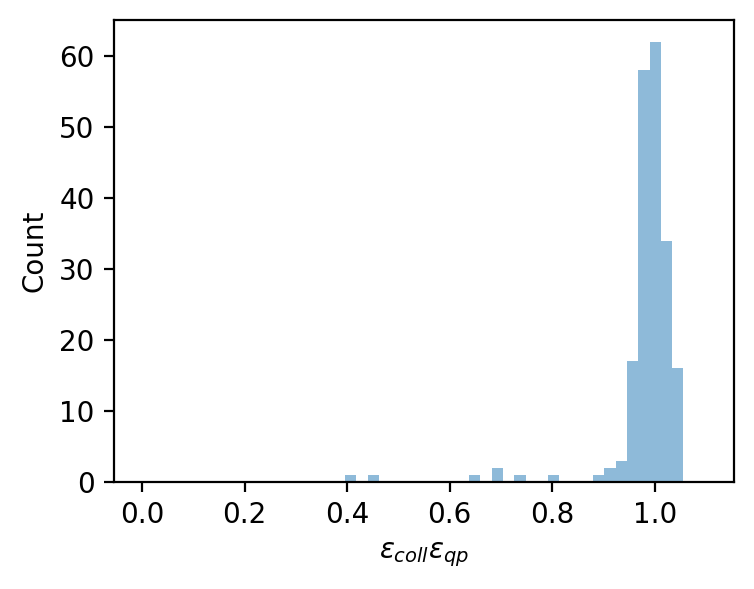

In [107]:
plt.figure(figsize=(4,3), dpi=200)
plt.hist(PhononEsum / Eph, np.linspace(0, 1.1, 51), alpha = 0.5)

plt.xlabel(r'$\epsilon_{coll} \epsilon_{qp}$')
plt.ylabel('Count')

We see a peak centered on 100% efficiency. We get some values above 100% because e_pair is only the *average* eh pair energy.
Below, we see that the events where the efficiency was <90% occurred close to the edges of the detector. This is because the charge hits the side-wall and recombines before full Luke amplification can occur.

Text(0, 0.5, 'Z position [mm]')

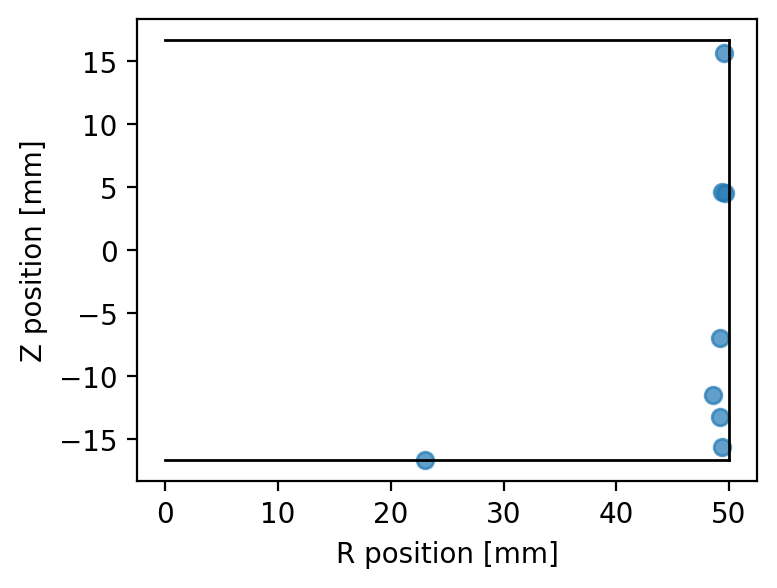

In [27]:
plt.figure(figsize=(4,3), dpi=200)
plt.scatter(R[(PhononEsum / Eph) < 0.9], Z[(PhononEsum / Eph) < 0.9], alpha = 0.7, label = 'hit positions')
plt.plot([0, 50], [-33.33/2, -33.33/2], lw = 1, color = 'black', label = 'detector outline')
plt.plot([0, 50], [33.33/2, 33.33/2], lw = 1, color = 'black')
plt.plot([50, 50], [-33.33/2, 33.33/2], lw = 1, color = 'black')

plt.xlabel('R position [mm]')
plt.ylabel('Z position [mm]')

We now look at the amount of energy that is lost by the TES converting a change of temperature to a change in current.
The loss mechanism here is the dissipation of power to the bath by thermal conductance.

We estimate the amount of energy that we converted into a change in current using<br>
$E_{abs} = -\int \Delta P_{Joule} dt = - \int (V_b - 2 I_0 R_l) \Delta I(t) dt + \int R_l (\Delta I(t))^2 dt$

In [92]:
# TESSim information is stored in 'G4SimDir/g4dmcTES' tree in the DMC file. Let's store the 'Trace' field.
g4dmcTES = CDataFrame('G4SimDir/g4dmcTES', DMCfiles)
EventNum = g4dmcTES.AsNumpy(['EventNum'])['EventNum']
Trace = g4dmcTES.AsNumpy(['Trace'])['Trace']

# Let's also store the 'ChanNum' and 'ChanName' fields. These tells us which phonon channel the trace belongs to (both the index chanNum and the name ChanName).
ChanName = g4dmcTES.AsNumpy(['ChanName'])['ChanName']
ChanNum  = g4dmcTES.AsNumpy(['ChanNum'])['ChanNum']

# Let's also get the starting time of the TES pulse T0 and the width of the timebins BinWidth. We can use this to set up the time array TimeBins in units of microseconds.
T0       = g4dmcTES.Filter(f'EventNum == 0').AsNumpy(['T0'])['T0'][0]
BinWidth = g4dmcTES.Filter(f'EventNum == 0').AsNumpy(['BinWidth'])['BinWidth'][0]
TimeBins = np.arange(T0, T0 + BinWidth * len(Trace[0]), BinWidth) * 1e-3 # ns -> us

In [93]:
def calcTESEff(trace, Rp, Rs, Rn_chan, RoverRn, BinWidth):
    J2eV = 6.242e18 # Joule -> eV
    
    I = trace * 1e-6 # uA -> A
    I0 = np.mean(I[:15000]) # A

    Rl = Rp + Rs # ohm
    R0 = RoverRn * Rn_chan # ohm
    Ib = I0 * (Rl + R0) / Rs # A
    Vb = Ib * Rs # V

    deltaI = I - I0 # A
    deltaI2 = deltaI * deltaI # A^2

    deltaPJoule = (2 * I0 * Rl - Vb) * deltaI + Rl * deltaI2 # Watt

    int_deltaPJoule = sum(deltaPJoule) * BinWidth * J2eV # eV

    return int_deltaPJoule

The values below are stored in [supersim TESConstants](https://gitlab.com/supercdms/Simulations/supersim/-/blob/master/CDMSgeometry/data/dmc/HV100mm/TESConstants?ref_type=heads)

In [100]:
Rb = 2500 # ohm
Rp = 1e-3 # ohm
Rs = 5e-3 # ohm
Rn_chan = 100e-3 # ohm
RoverRn = 0.333333

BinWidth = 1.6e-6 # s

In [103]:
Eabs = []
for i in range(len(Trace)):
    Eabs.append(calcTESEff(Trace[i], Rp, Rs, Rn_chan, RoverRn, BinWidth))

Eabs = np.array(Eabs)

In [104]:
Eabs_sum = np.array([sum(Eabs[EventNum==event]) for event in np.unique(EventNum)])

Text(0, 0.5, 'Count')

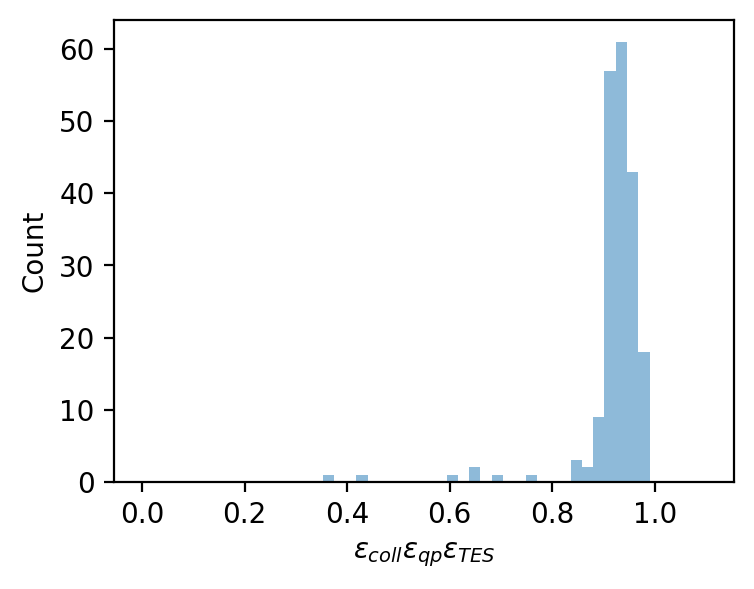

In [106]:
plt.figure(figsize=(4,3), dpi=200)
plt.hist(Eabs_sum / Eph, np.linspace(0, 1.1, 51), alpha = 0.5)

plt.xlabel(r'$\epsilon_{coll} \epsilon_{qp} \epsilon_{TES}$')
plt.ylabel('Count')